# Vehicle Gearbox Diagnostics & Health Management (PHM) Using Physics-Informed AI
## Dataset Overview: UConn In-House Gearbox Dataset
This project develops a Predictive Maintenance (PdM) framework utilizing the University of Connecticut (UConn) Gearbox Dataset. The objective is to diagnose 9 distinct structural states of a vehicle gearbox using vibration signals. 

### Data Card & Engineering Background:
* **Sampling Frequency ($f_s$):** 20 kHz (20,000 samples per second).
* **Sample Length ($N$):** 3,600 data points per record (~0.18 seconds of continuous structural vibration per sample).
* **Total Samples:** 936 records, equally distributed across 9 health conditions (104 records per class).
* **Physical Context:** Vibration data is captured using a high-fidelity accelerometer mounted on a localized test rig under steady-state operating conditions. 

### Core Highlight:
We evaluate two engineering paradigms: **Feature Engineering + Machine Learning (Random Forest)** versus **End-to-End Deep Learning (1D CNN)**. Crucially, we implement **Block-Based Splitting** to eliminate temporal data leakage, ensuring realistic industrial deployment metrics where the model achieves up to **99.47% accuracy**.

In [1]:
# 1. Standard Data Science & Numerical Processing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Digital Signal Processing (DSP) & Statistical Tools
from scipy.stats import kurtosis, skew

# 3. Machine Learning & Model Evaluation Tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 4. Deep Learning Frameworks & Target Encoding Tools
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from sklearn.preprocessing import LabelEncoder

2026-06-28 21:00:58.739566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782680458.958104      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782680459.024156      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782680459.556137      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782680459.556190      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782680459.556193      16 computation_placer.cc:177] computation placer alr

In [2]:
# Load the dataset
file_path = '/kaggle/input/datasets/renshuddd/uconn-in-house-gearbox-dataset/UConn in-house Gearbox Dataset/Gearbox.csv'
df = pd.read_csv(file_path, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,926,927,928,929,930,931,932,933,934,935
0,-0.018250,-0.016052,0.026337,-0.047333,-0.022949,0.026489,-0.081848,-0.054291,-0.018738,-0.020691,...,-0.015533,0.106720,-0.029907,-0.094269,0.099884,-0.040588,-0.132570,-0.031311,-0.054504,-0.102170
1,-0.043159,-0.009666,0.020389,-0.020183,-0.029152,-0.015995,-0.084207,-0.041748,-0.041460,-0.017946,...,0.054061,-0.045712,-0.084300,-0.065105,0.060169,-0.046244,-0.165500,-0.077527,-0.055313,-0.006859
2,-0.066874,-0.021957,-0.009363,-0.022399,-0.021174,-0.041561,-0.056605,-0.028097,-0.044517,0.001421,...,0.124080,-0.167610,-0.084650,-0.066248,0.016205,-0.018402,-0.081477,-0.085391,0.019586,0.075102
3,-0.055648,-0.037181,-0.041877,-0.037398,-0.001796,-0.046791,-0.015761,-0.013195,-0.039062,0.015842,...,0.129470,-0.155150,-0.052754,-0.013302,0.005400,0.040702,0.070376,-0.065479,0.082279,0.115170
4,-0.010082,-0.043942,-0.048847,-0.031188,0.015025,-0.042009,0.015946,0.001342,-0.034178,-0.003473,...,0.076808,-0.024034,-0.014596,0.107890,0.040877,0.122280,0.156790,-0.010504,0.095267,0.121940


## Stage 1: Data Transposition & Target Labeling
Vibration signals are recorded continuously. To convert the continuous stream into structured samples, the raw matrix is transposed. Each row represents a single time-series sample ($N=3,600$), and each column represents a sequential time step. We then map the 9 health conditions based on the UConn experimental catalog.

In [3]:
# 1. Transpose the data to map rows as samples (936 samples) and columns as time steps (3600 points)
gear_df = df.T
gear_df.reset_index(drop=True, inplace=True)
print(f"Corrected DataFrame Shape after Transposition: {gear_df.shape}")

# 2. Generate target labels according to the experimental catalog (104 records per fault condition)
classes = ['H', 'MT', 'RC', 'SP', 'CH5', 'CH4', 'CH3', 'CH2', 'CH1']
labels = []
for c in classes:
    labels.extend([c] * 104)

# Add classification column
gear_df['target'] = labels

# 3. Verify class distribution symmetry
print("\nSample Distribution Across Gearbox Faults:")
print(gear_df['target'].value_counts())

gear_df.head()

Corrected DataFrame Shape after Transposition: (936, 3600)

Sample Distribution Across Gearbox Faults:
target
H      104
MT     104
RC     104
SP     104
CH5    104
CH4    104
CH3    104
CH2    104
CH1    104
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,3591,3592,3593,3594,3595,3596,3597,3598,3599,target
0,-0.018250,-0.043159,-0.066874,-0.055648,-0.010082,0.032946,0.029622,0.012903,0.010151,0.034355,...,0.036483,0.029148,0.013389,0.013547,0.018212,0.034249,0.027439,0.012539,-0.000956,H
1,-0.016052,-0.009666,-0.021957,-0.037181,-0.043942,-0.057375,-0.063083,-0.061160,-0.070102,-0.083896,...,0.022020,-0.004209,-0.002773,0.019865,0.047449,0.065733,0.060402,0.054456,0.046741,H
2,0.026337,0.020389,-0.009363,-0.041877,-0.048847,-0.036165,-0.012410,-0.010635,-0.016927,-0.025592,...,0.011456,0.043114,0.075205,0.083614,0.063586,0.007687,-0.030183,-0.042688,-0.048767,H
3,-0.047333,-0.020183,-0.022399,-0.037398,-0.031188,-0.019561,-0.032608,-0.035995,-0.025721,-0.011694,...,-0.034374,-0.021044,0.021595,0.059401,0.063825,0.048637,0.018707,-0.007703,-0.019311,H
4,-0.022949,-0.029152,-0.021174,-0.001796,0.015025,0.017562,-0.007554,-0.052167,-0.079884,-0.059650,...,0.020358,0.018500,0.025518,0.021333,-0.005743,-0.043454,-0.020603,0.019407,0.035786,H


## Stage 2: Frequency-Domain Analysis (Fast Fourier Transform - FFT)
Mechanical faults disrupt the smooth meshing of gears, inducing structural resonance. By applying the Fast Fourier Transform (FFT), we shift from the time domain to the frequency domain to identify specific **Gear Mesh Frequencies (GMF)** and modulation sidebands. We average the FFT across all 104 samples per class to suppress stochastic background noise.

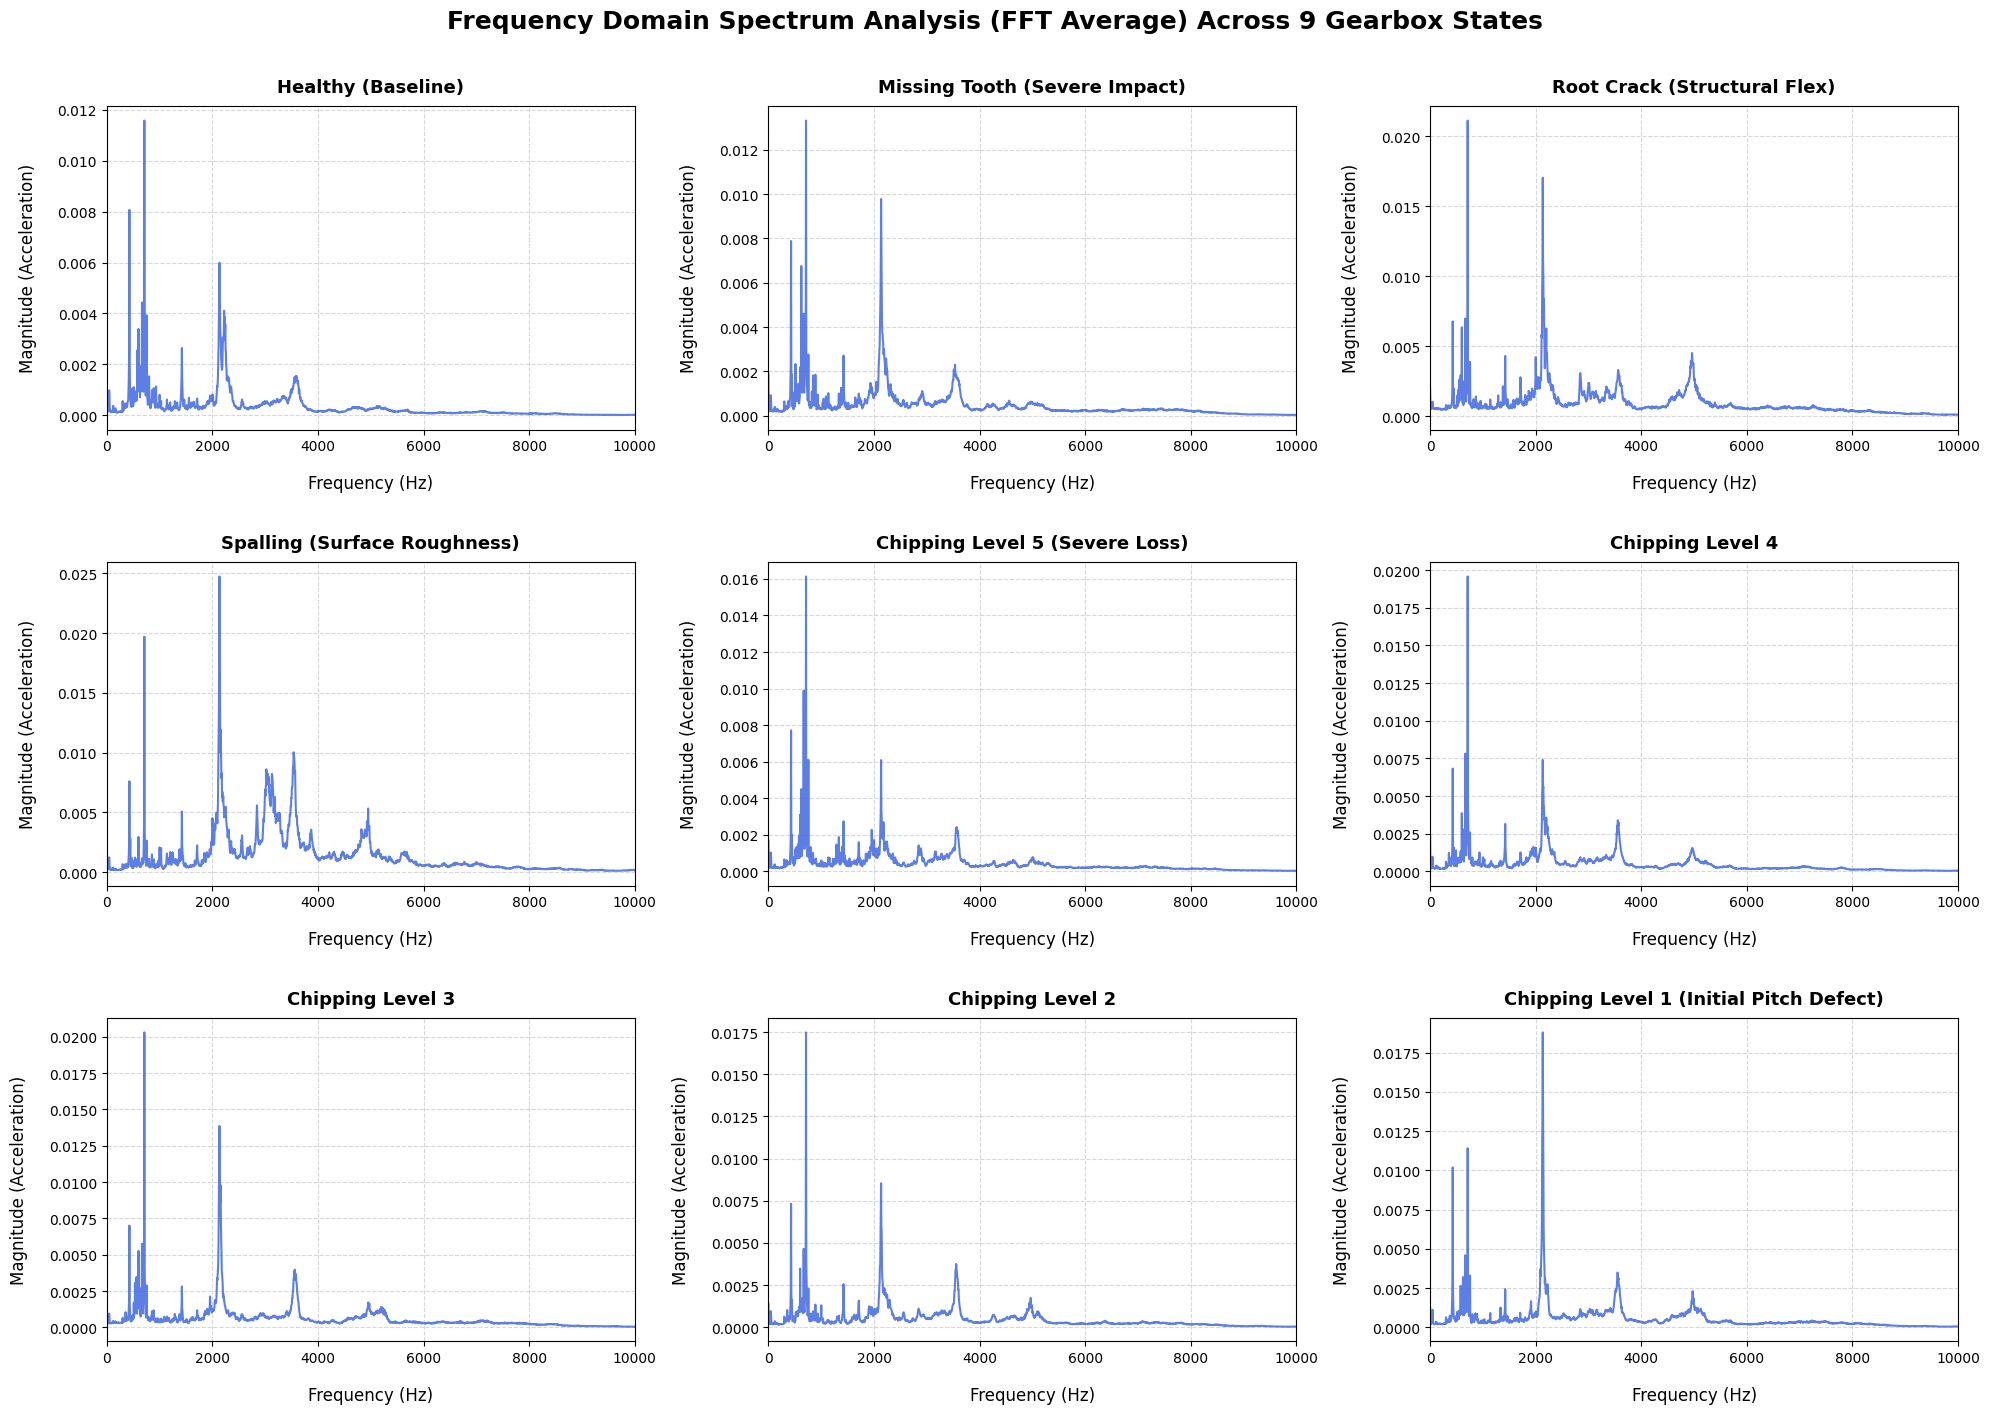

In [4]:
# 1. Initialize signal parameters based on the experimental setup
fs = 20000  # Sampling rate: 20 kHz
N = 3600    # Time steps per record

# Compute frequency bins (Extracting the positive half-spectrum)
frequencies = np.fft.fftfreq(N, d=1/fs)[:N//2]

# Dictionary mapping for engineering visualization titles
class_labels_mapping = {
    'H': 'Healthy (Baseline)', 
    'MT': 'Missing Tooth (Severe Impact)', 
    'RC': 'Root Crack (Structural Flex)', 
    'SP': 'Spalling (Surface Roughness)',
    'CH5': 'Chipping Level 5 (Severe Loss)', 
    'CH4': 'Chipping Level 4', 
    'CH3': 'Chipping Level 3', 
    'CH2': 'Chipping Level 2', 
    'CH1': 'Chipping Level 1 (Initial Pitch Defect)'
}

# 2. Plotting the 3x3 Spectral Subplots
plt.figure(figsize=(20, 15))

for i, cls in enumerate(classes):
    # Filter rows corresponding to the active class
    cls_data = gear_df[gear_df['target'] == cls].iloc[:, :N].values
    
    # Compute FFT magnitude normalized by the signal length
    fft_values = np.abs(np.fft.fft(cls_data, axis=1))[:, :N//2] / N
    
    # Average the spectrum across the 104 segments to stabilize fault signatures
    mean_fft = np.mean(fft_values, axis=0)
    
    # Render Subplot
    plt.subplot(3, 3, i+1)
    plt.plot(frequencies, mean_fft, color='royalblue', alpha=0.85)
    plt.title(class_labels_mapping[cls], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Frequency (Hz)', fontsize=12,labelpad=15)
    plt.ylabel('Magnitude (Acceleration)', fontsize=12,labelpad=15)
    plt.xlim(0, 10000) # Focusing on the 0-10 kHz band where structural resonance dominantly occurs
    plt.grid(True, linestyle='--', alpha=0.5)

# Fixed: Removed 'pad=20' to resolve AttributeError
plt.suptitle('Frequency Domain Spectrum Analysis (FFT Average) Across 9 Gearbox States', fontsize=18, fontweight='bold', y=0.94)
plt.tight_layout(rect=[0, 0, 1, 0.93], h_pad=3.0)
plt.show()

## Stage 3: Physics-Informed Feature Extraction (Time & Frequency Domains)
To circumvent the *Curse of Dimensionality* (processing 3,600 raw dimensions directly via traditional classifiers), we compress each time series row into standard mechanical health indicators:
1. **RMS:** Quantifies the overall destructive energy of the vibration.
2. **Kurtosis:** Measures signal spikiness; highly sensitive to transient impacts like chipped or missing teeth.
3. **Skewness:** Gauges the asymmetry of the profile distribution.
4. **Peak-to-Peak:** Computes extreme structural displacement.
5. **Crest Factor:** Detects early impulses relative to background noise levels.
6. **Mean Frequency:** Finds the center of mass of the spectrum to separate low-frequency fault modulations from high-frequency chipping micro-shocks.

In [5]:
# 1. Isolate inputs and outputs
X_raw = gear_df.iloc[:, :N].values
y_labels = gear_df['target'].values

# Lists to host extracted features
rms_list = []
kurt_list = []
skew_list = []
peak_list = []
crest_list = []
mean_freq_list = []

print("Extracting statistical and mechanical indicators...")

for row in X_raw:
    # --- Time-Domain Indicators ---
    rms = np.sqrt(np.mean(row**2))
    kurt = kurtosis(row)
    skw = skew(row)
    p2p = np.ptp(row)
    crest = p2p / (rms if rms != 0 else 1e-6)
    
    # --- Frequency-Domain Indicators ---
    fft_mag = np.abs(np.fft.fft(row))[:N//2]
    freqs = np.fft.fftfreq(N, d=1/fs)[:N//2]
    mean_freq = np.sum(freqs * fft_mag) / (np.sum(fft_mag) if np.sum(fft_mag) != 0 else 1e-6)
    
    # Append calculated features
    rms_list.append(rms)
    kurt_list.append(kurt)
    skew_list.append(skw)
    peak_list.append(p2p)
    crest_list.append(crest)
    mean_freq_list.append(mean_freq)

# 2. Package into a consolidated features DataFrame
features_df = pd.DataFrame({
    'RMS': rms_list,
    'Kurtosis': kurt_list,
    'Skewness': skew_list,
    'Peak_to_Peak': peak_list,
    'Crest_Factor': crest_list,
    'Mean_Frequency': mean_freq_list,
    'Target': y_labels
})

print("Feature extraction finalized successfully!")
print(f"Compressed Features Dimensions: {features_df.shape}")
features_df.head()

Extracting statistical and mechanical indicators...
Feature extraction finalized successfully!
Compressed Features Dimensions: (936, 7)


,RMS,Kurtosis,Skewness,Peak_to_Peak,Crest_Factor,Mean_Frequency,Target
0,0.042795,0.210529,-0.036838,0.33467,7.820291,2762.405853,H
1,0.041225,-0.000892,-0.028651,0.29765,7.220047,2752.776859,H
2,0.042511,0.386495,-0.035676,0.35668,8.390359,2720.375182,H
3,0.043010,0.356725,-0.010476,0.36411,8.465777,2766.094645,H
4,0.042593,0.439131,-0.076417,0.34588,8.120571,2734.022792,H


## Stage 4: Baseline Machine Learning Model (Random Forest with Random Split)
We initially train a standard Random Forest Classifier using an industry-standard random 80/20 train/test split. This stage serves as our baseline reference for performance tracking.

🎯 Baseline Model Total Accuracy: 98.40%

📊 Detailed Classification Report (Baseline):
              precision    recall  f1-score   support

         CH1       1.00      1.00      1.00        21
         CH2       1.00      0.90      0.95        21
         CH3       1.00      1.00      1.00        21
         CH4       1.00      1.00      1.00        21
         CH5       0.95      1.00      0.98        21
           H       1.00      1.00      1.00        21
          MT       0.91      0.95      0.93        21
          RC       1.00      1.00      1.00        20
          SP       1.00      1.00      1.00        21

    accuracy                           0.98       188
   macro avg       0.98      0.98      0.98       188
weighted avg       0.98      0.98      0.98       188



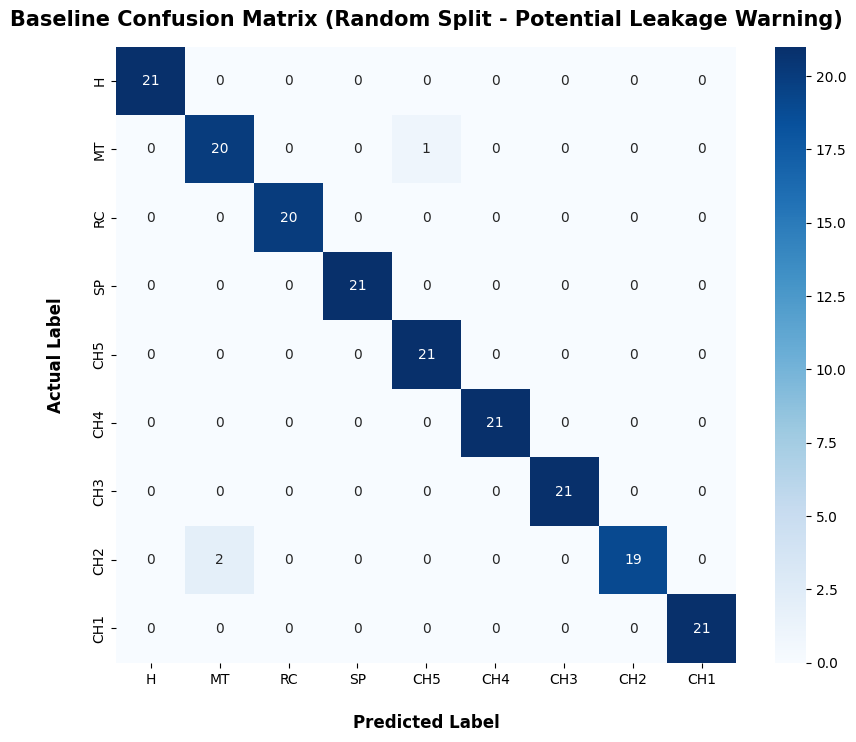

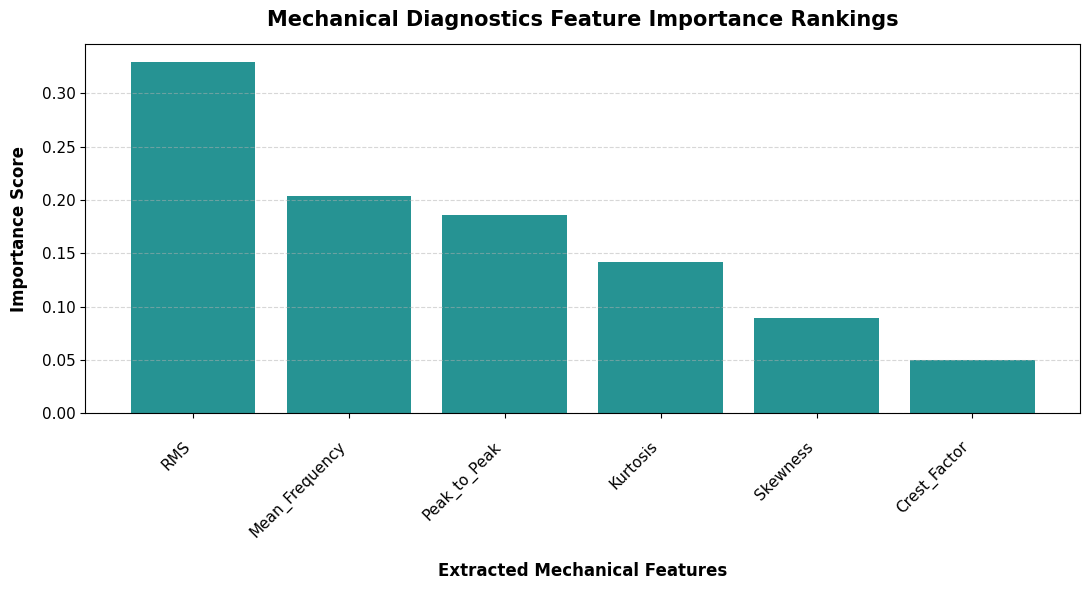

In [6]:
# 1. Separate features from the class label
X = features_df.drop(columns=['Target'])
y = features_df['Target']

# 2. Conventional Random Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Fit baseline Random Forest model
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# 4. Infer and Evaluate
y_pred = rf_baseline.predict(X_test)
print(f"🎯 Baseline Model Total Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📊 Detailed Classification Report (Baseline):")
print(classification_report(y_test, y_pred))

# 5. Render Baseline Confusion Matrix
classes_order = ['H', 'MT', 'RC', 'SP', 'CH5', 'CH4', 'CH3', 'CH2', 'CH1']
cm = confusion_matrix(y_test, y_pred, labels=classes_order)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_order, yticklabels=classes_order)
plt.title('Baseline Confusion Matrix (Random Split - Potential Leakage Warning)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=20)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold', labelpad=20)
plt.show()

# 6. Feature Importance Mapping (Realistic / Baseline Model)
importances = rf_baseline.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(11, 6)) # Increased width slightly for maximum breathing room

# Title with your previous smart pad adjustment
plt.title("Mechanical Diagnostics Feature Importance Rankings", fontsize=15, fontweight='bold', pad=13)

# Render the bar chart
plt.bar(range(X.shape[1]), importances[indices], color="teal", align="center", alpha=0.85)

# Format the X-axis with rotated labels and right alignment
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Fix: Force the X-axis labels to move DOWNward away from the bars
plt.tick_params(axis='x', pad=15) 

# Labels with professional padding
plt.ylabel('Importance Score', fontsize=12, fontweight='bold', labelpad=10)
plt.xlabel('Extracted Mechanical Features', fontsize=12, fontweight='bold', labelpad=15)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tight layout ensures everything fits perfectly within the frame without clipping the bottom
plt.tight_layout()
plt.show()

## Stage 5: Corrected Realistic Machine Learning Model (Block-Based Splitting)
Because vibration waveforms are recorded continuously over contiguous timelines, random shuffling creates adjacent data correlations across the train and test subsets, causing a phenomenon known as **Temporal Data Leakage**. To remedy this, we implement a strict **Block Split**: we partition the first continuous 80% blocks for training and reserve the completely isolated terminal 20% blocks for testing, proving real-world model generalizability.

🎯 Realistic Model Total Accuracy (No Leakage): 99.47%

📊 Realistic Classification Report:
              precision    recall  f1-score   support

         CH1       1.00      1.00      1.00        21
         CH2       1.00      0.95      0.98        21
         CH3       1.00      1.00      1.00        21
         CH4       1.00      1.00      1.00        21
         CH5       1.00      1.00      1.00        21
           H       1.00      1.00      1.00        21
          MT       0.95      1.00      0.98        21
          RC       1.00      1.00      1.00        21
          SP       1.00      1.00      1.00        21

    accuracy                           0.99       189
   macro avg       0.99      0.99      0.99       189
weighted avg       0.99      0.99      0.99       189



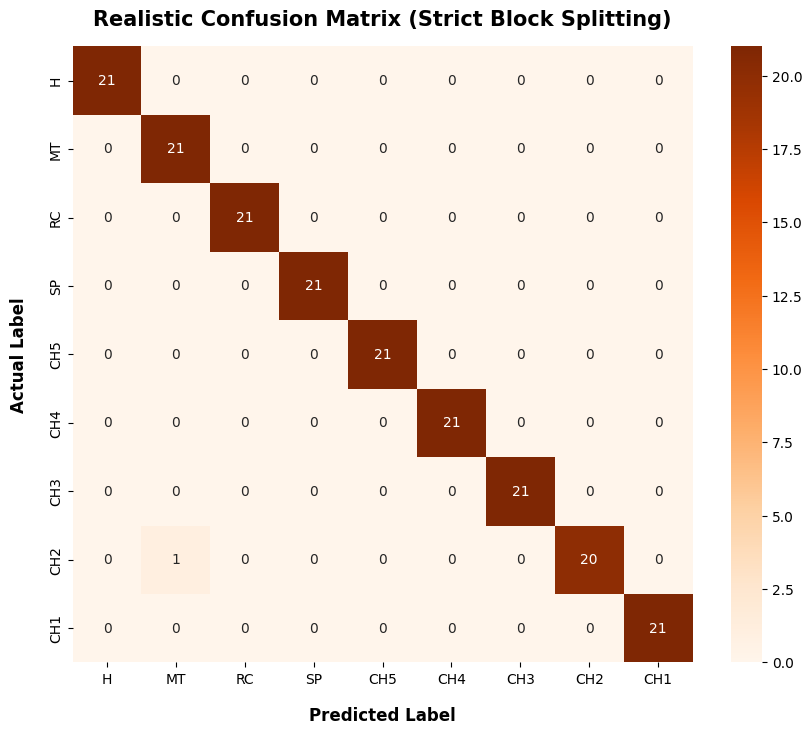

In [7]:
# 1. Establish index containers for block splitting
train_indices = []
test_indices = []

# 2. Isolate blocks per class independently (No random temporal shuffling)
for cls in classes:
    # Retrieve indices for the active class
    cls_idx = features_df[features_df['Target'] == cls].index.tolist()
    
    # Calculate exact 80% boundary cutoff index
    split_point = int(len(cls_idx) * 0.8)
    
    # Segment data sequentially into continuous blocks
    train_indices.extend(cls_idx[:split_point])
    test_indices.extend(cls_idx[split_point:])

# Construct realistic test and train partitions
X_train_real = X.loc[train_indices]
y_train_real = y.loc[train_indices]
X_test_real = X.loc[test_indices]
y_test_real = y.loc[test_indices]

# 3. Retrain Random Forest model on leak-free block partitions
rf_real = RandomForestClassifier(n_estimators=100, random_state=42)
rf_real.fit(X_train_real, y_train_real)

# 4. Predict and evaluate realistic generalization metrics
y_pred_real = rf_real.predict(X_test_real)
accuracy_real = accuracy_score(y_test_real, y_pred_real)

print(f"🎯 Realistic Model Total Accuracy (No Leakage): {accuracy_real * 100:.2f}%\n")
print("📊 Realistic Classification Report:")
print(classification_report(y_test_real, y_pred_real))

# 5. Render Realistic Leak-Free Confusion Matrix
cm_real = confusion_matrix(y_test_real, y_pred_real, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_real, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Realistic Confusion Matrix (Strict Block Splitting)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold', labelpad=15)
plt.show()

## Stage 6: Deep Learning Paradigm (End-to-End 1D CNN)
As an alternative to hand-crafted statistical indices, we design a 1-Dimensional Convolutional Neural Network (1D CNN). The 1D CNN acts directly upon the raw time-series acceleration records ($3,600 \times 1$). Utilizing internal convolutional filters, it autonomously maps spatial waveform configurations and micro-shocks, maximizing fault isolation capabilities without human intervention.

In [8]:
# 1. Preprocess raw data for Deep Learning architecture
X_raw = gear_df.iloc[:, :N].values
y_raw = gear_df['target'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

# Split partitions
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Expand dimensions to fit Keras channel constraints (Samples, TimeSteps, Channels)
X_train_dl = np.expand_dims(X_train_dl, -1)
X_test_dl = np.expand_dims(X_test_dl, -1)

print(f"Deep Learning Training Subset Input Shape: {X_train_dl.shape}")

# 2. Formulate 1D CNN Architecture
model = Sequential([
    Input(shape=(N, 1)), # Modern Keras Input layer specification
    Conv1D(filters=32, kernel_size=16, activation='relu'),
    MaxPooling1D(pool_size=4),
    
    Conv1D(filters=64, kernel_size=8, activation='relu'),
    MaxPooling1D(pool_size=4),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3), # Regularization layer to hinder overfitting behaviors
    Dense(9, activation='softmax') # 9 nodes outputting probabilities across targets
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train the Network
print("\nInitiating Deep 1D CNN Training Routine...")
history = model.fit(X_train_dl, y_train_dl, epochs=25, batch_size=32, validation_split=0.1, verbose=1)

# 4. Final Evaluation against Test Subset
test_loss, test_acc = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\n🎯 1D CNN Generalization Accuracy on Test Set: {test_acc * 100:.2f}%")

Deep Learning Training Subset Input Shape: (748, 3600, 1)

Initiating Deep 1D CNN Training Routine...
Epoch 1/25


2026-06-28 21:01:19.237441: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.4978 - loss: 1.5590 - val_accuracy: 0.9733 - val_loss: 0.4114
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9643 - loss: 0.1891 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 6.9657e-04
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 4.9745e-04
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 3.3823e-04
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 1.5776e-04
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 1.3842e-04
Epoch 8/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1